In [12]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything

seed_everything(12345)
scvi.settings.seed = 12345

Seed set to 12345
Seed set to 12345


In [13]:
adata = sc.read_h5ad('../../data/talbot_xenium_tumor_annotated_updated.h5ad')

In [14]:
ad = sc.read_h5ad('../../data/talbot_xenium.h5ad')
ad = ad[ad.obs.tissue == 'tumor']
ad

View of AnnData object with n_obs × n_vars = 279424 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    obsm: 'spatial'

In [15]:
# Subset ad to the cells present in adata (same order), then store raw counts
adata.layers['counts'] = ad[adata.obs_names].X.copy()

In [16]:
adata.layers['counts']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 57909027 stored elements and shape (207468, 5006)>

In [18]:
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="counts", 
    batch_key='sample_id',
)

model = scvi.model.SCVI(adata)

In [19]:
model.train(early_stopping=True, enable_progress_bar=True)


/Users/christoffer/miniconda3/envs/cellcharter-env/lib/python3.12/site-packages/scvi/train/_trainrunner.py:84: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/christoffer/miniconda3/envs/cellcharter-env/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Epoch 39/39: 100%|██████████| 39/39 [26:53<00:00, 39.86s/it, v_num=1, train_loss=805]

`Trainer.fit` stopped: `max_epochs=39` reached.


Epoch 39/39: 100%|██████████| 39/39 [26:53<00:00, 41.37s/it, v_num=1, train_loss=805]


In [20]:
adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)


In [21]:
sq.gr.spatial_neighbors(adata, library_key='sample_id', coord_type='generic', delaunay=True, percentile=99)


In [22]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI', out_key='X_cellcharter', sample_key='sample')


100%|██████████| 4/4 [00:00<00:00,  9.98it/s]


In [23]:
# GMM components to try
# GMM components to try
gmm_components = [15,20]

In [24]:
from sklearn.mixture import GaussianMixture
import pandas as pd

X = adata.obsm['X_cellcharter']
gmm_results = []

for k in gmm_components:
    print(k)
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=0,
        n_init=3,
    )
    labels = gmm.fit_predict(X)
    key = f'CellCharter_{k}'
    adata.obs[key] = labels.astype(str)
    gmm_results.append({
        'k': k,
        'bic': gmm.bic(X),
        'aic': gmm.aic(X),
    })
    n_clusters = adata.obs[key].nunique()
    print(f'k={k}: {n_clusters} clusters')


15
k=15: 15 clusters
20
k=20: 20 clusters


In [25]:
adata

AnnData object with n_obs × n_vars = 207468 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'leiden_4', 'cytetype_annotation_leiden_4', 'cytetype_cellOntologyTerm_leiden_4', 'cytetype_cellOntologyTermID_leiden_4', 'cytetype_cellState_leiden_4', '_scvi_batch', '_scvi_labels', 'CellCharter_15', 'CellCharter_20'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_symbols'
    uns: 'cytetype_jobDetails', 'cytetype_results', 'genotype_colors', 'leiden', 'leiden_0.5_co

In [27]:
import sys
sys.path.append("/Users/christoffer/work/karolinska/development/MANA")
from utils import aggregate_neighbors_weighted, plot_spatial_compact_fast

Plotting CellCharter_15 …


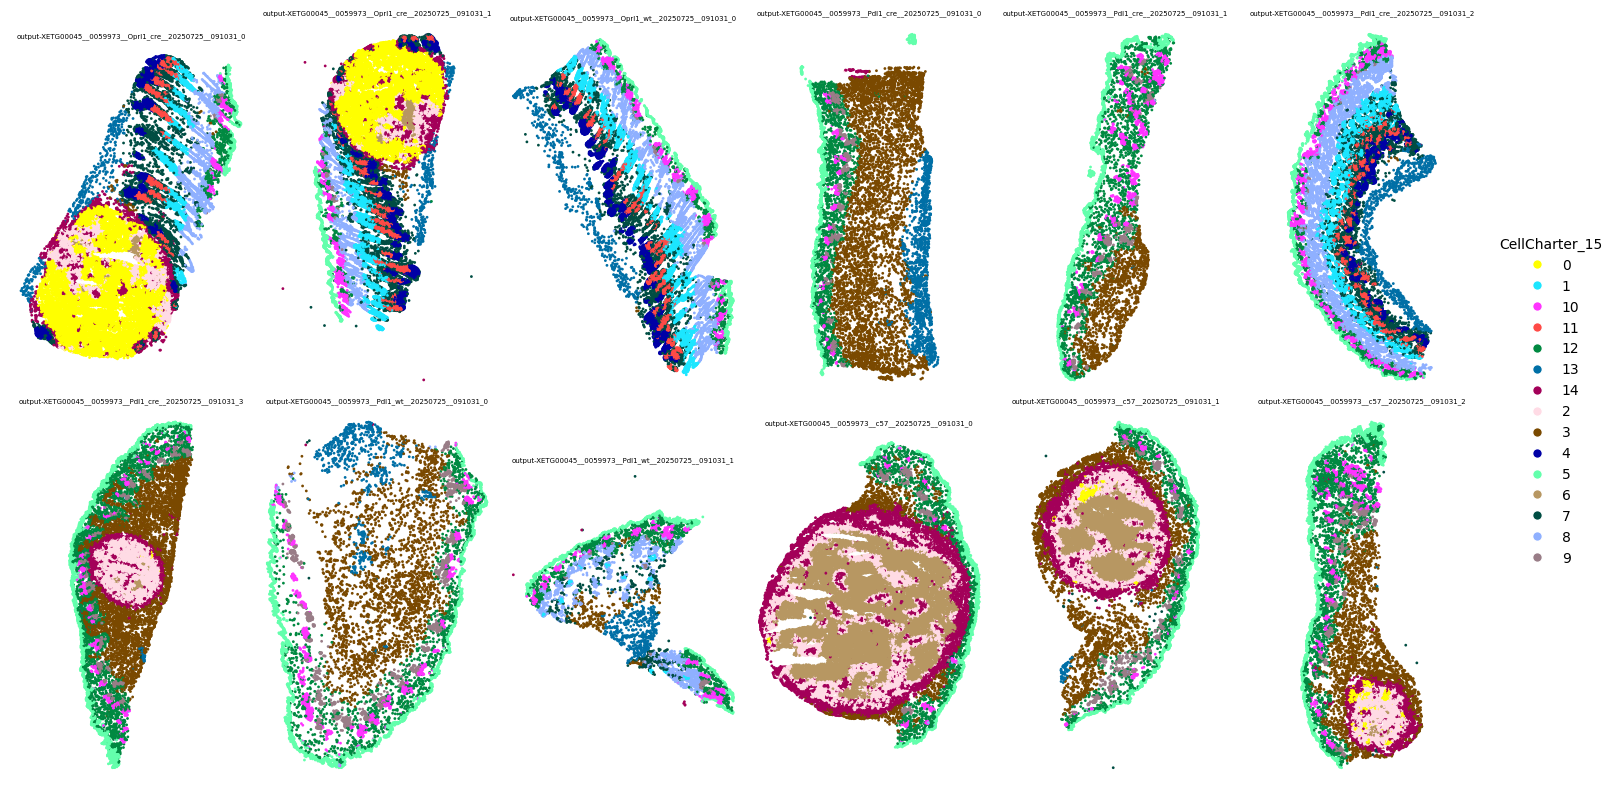

Plotting CellCharter_20 …


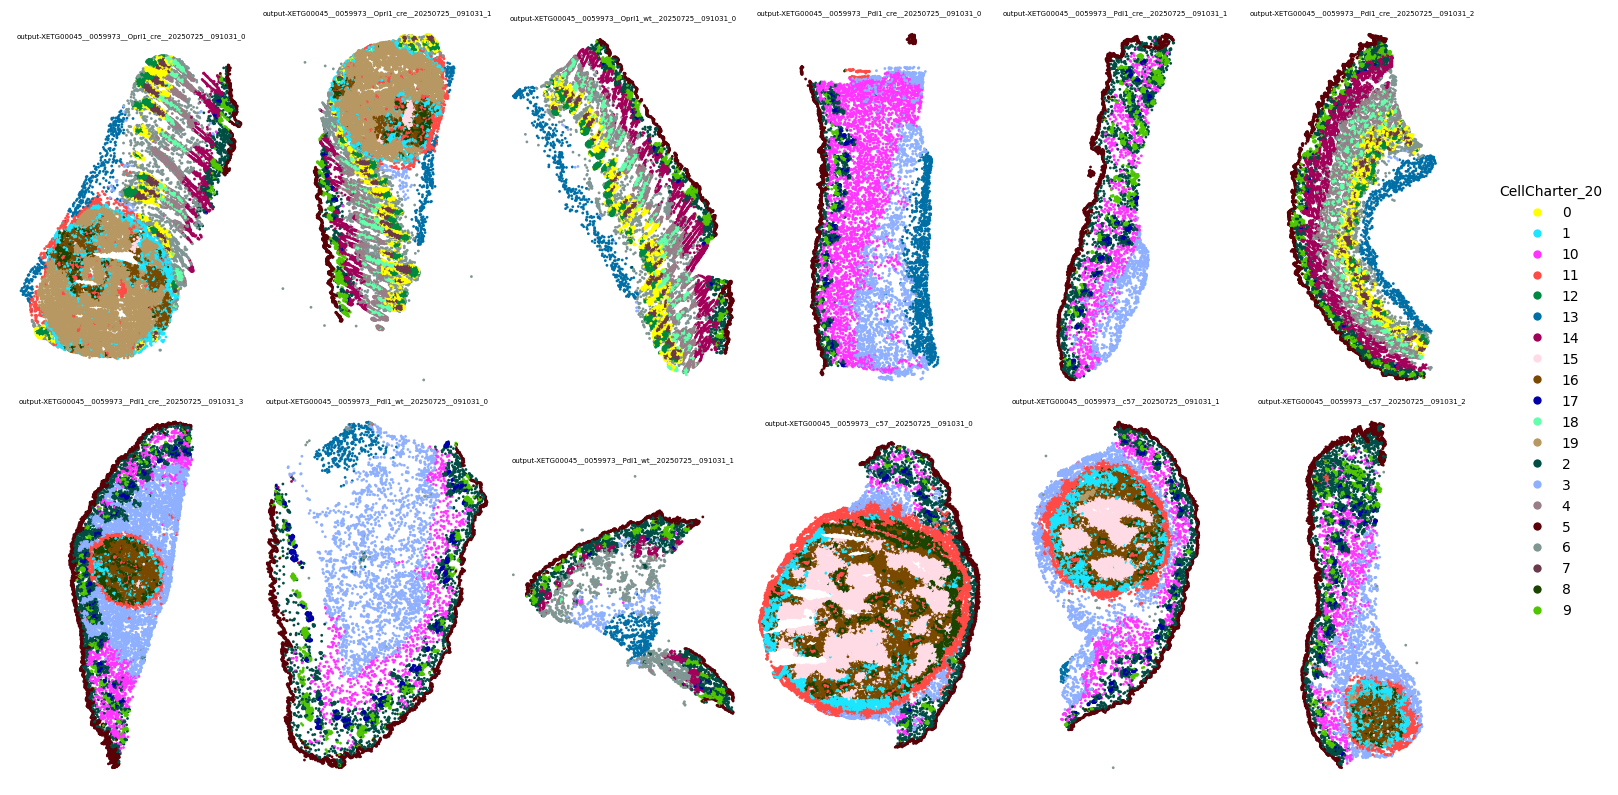

In [29]:
for domain in ['CellCharter_15', 'CellCharter_20']:
    if domain in adata.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata,
            color=domain,
            groupby="sample_id",
            spot_size=4,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")

In [30]:
adata.write('../../data/talbot_xenium_tumor_annotated_updated_cellcharter.h5ad')